<a href="https://colab.research.google.com/github/matjekolenka-phd/workshop_python_/blob/main/Time_Series_Homework.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Time Series Homework

This notebook uses monthly maternal and newborn health data.

The aim is to:
1. Load time-series/panel data
2. Explore trends over time
3. Create rolling averages
4. Decompose the time series into trend, seasonality, and residuals
5. Build a simple prediction model
6. Prepare files for tomorrow’s app

# Install Libraries

In [ ]:
!pip install pandas
!pip install numpy
!pip install matplotlib
!pip install seaborn
!pip install scikit-learn
!pip install xgboost
!pip install statsmodels

# Import Libraries

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split

from xgboost import XGBRegressor

# Upload File

In [ ]:
uploaded = files.upload()

Saving 02_monthly_mnh_panel_time_series.csv to 02_monthly_mnh_panel_time_series (1).csv


# Read the file

In [ ]:
file_name = list(uploaded.keys())[0]

df = pd.read_csv(file_name)

df.head()

,date,year,month,district,live_births,maternal_deaths,neonatal_deaths,deaths_notified_within_24h,deaths_reviewed_within_7d,actions_completed,data_completeness_pct
0,01/01/2024,2024,1,Maseru,726,0,10,7,6,6,88
1,01/02/2024,2024,2,Maseru,758,2,8,9,7,6,85
2,01/03/2024,2024,3,Maseru,774,0,17,14,13,12,100
3,01/04/2024,2024,4,Maseru,730,0,5,4,3,2,94
4,01/05/2024,2024,5,Maseru,780,0,9,8,7,6,72


# Check the dataset

In [ ]:
print("Dataset shape:")
print(df.shape)

print("\nColumn names:")
print(df.columns)

print("\nDataset information:")
df.info()

Dataset shape:
(144, 11)

Column names:
Index(['date', 'year', 'month', 'district', 'live_births', 'maternal_deaths',
       'neonatal_deaths', 'deaths_notified_within_24h',
       'deaths_reviewed_within_7d', 'actions_completed',
       'data_completeness_pct'],
      dtype='object')

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   date                        144 non-null    object
 1   year                        144 non-null    int64 
 2   month                       144 non-null    int64 
 3   district                    144 non-null    object
 4   live_births                 144 non-null    int64 
 5   maternal_deaths             144 non-null    int64 
 6   neonatal_deaths             144 non-null    int64 
 7   deaths_notified_within_24h  144 non-null    int64 
 8   deaths_reviewed_within

# Check missing values and duplicates

In [ ]:
print("Missing values per column:")
print(df.isnull().sum())

print("\nNumber of duplicate rows:")
print(df.duplicated().sum())

Missing values per column:
date                          0
year                          0
month                         0
district                      0
live_births                   0
maternal_deaths               0
neonatal_deaths               0
deaths_notified_within_24h    0
deaths_reviewed_within_7d     0
actions_completed             0
data_completeness_pct         0
dtype: int64

Number of duplicate rows:
0


# Convert date column to proper date format

In [ ]:
df["date"] = pd.to_datetime(df["date"])

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   date                        144 non-null    datetime64[ns]
 1   year                        144 non-null    int64         
 2   month                       144 non-null    int64         
 3   district                    144 non-null    object        
 4   live_births                 144 non-null    int64         
 5   maternal_deaths             144 non-null    int64         
 6   neonatal_deaths             144 non-null    int64         
 7   deaths_notified_within_24h  144 non-null    int64         
 8   deaths_reviewed_within_7d   144 non-null    int64         
 9   actions_completed           144 non-null    int64         
 10  data_completeness_pct       144 non-null    int64         
dtypes: datetime64[ns](1), int64(9), object(1)
memory usage: 12

# Basic summary statistics

In [ ]:
df.describe()

,date,year,month,live_births,maternal_deaths,neonatal_deaths,deaths_notified_within_24h,deaths_reviewed_within_7d,actions_completed,data_completeness_pct
count,144,144.000000,144.000000,144.000000,144.000000,144.000000,144.000000,144.000000,144.000000,144.000000
mean,2024-07-07 12:00:00,2024.500000,6.500000,356.590278,0.243056,4.416667,3.402778,2.701389,2.104167,88.159722
min,2024-01-01 00:00:00,2024.000000,1.000000,129.000000,0.000000,0.000000,0.000000,0.000000,0.000000,69.000000
25%,2024-01-06 18:00:00,2024.000000,3.750000,187.000000,0.000000,2.000000,0.000000,0.000000,0.000000,83.000000
50%,2024-07-07 12:00:00,2024.500000,6.500000,277.500000,0.000000,4.000000,3.000000,2.000000,1.000000,88.000000
75%,2025-01-06 06:00:00,2025.000000,9.250000,516.750000,0.000000,6.000000,5.000000,4.000000,3.000000,93.000000
max,2025-01-12 00:00:00,2025.000000,12.000000,790.000000,3.000000,17.000000,16.000000,15.000000,15.000000,100.000000
std,NaN,0.501745,3.464102,202.489417,0.570198,3.440808,3.518819,3.241082,3.021413,7.175778


# Check districts and time period

In [ ]:
print("Districts in the dataset:")
print(df["district"].unique())

print("\nStart date:")
print(df["date"].min())

print("\nEnd date:")
print(df["date"].max())

Districts in the dataset:
['Maseru' 'Mafeteng' 'Butha-Buthe' 'Leribe' 'Mokhotlong' 'Quthing']

Start date:
2024-01-01 00:00:00

End date:
2025-01-12 00:00:00


# Create monthly total dataset

In [ ]:
monthly = df.groupby("date").agg({
    "live_births": "sum",
    "maternal_deaths": "sum",
    "neonatal_deaths": "sum",
    "deaths_notified_within_24h": "sum",
    "deaths_reviewed_within_7d": "sum",
    "actions_completed": "sum",
    "data_completeness_pct": "mean"
}).reset_index()

monthly.head()

,date,live_births,maternal_deaths,neonatal_deaths,deaths_notified_within_24h,deaths_reviewed_within_7d,actions_completed,data_completeness_pct
0,2024-01-01,2177,0,30,19,16,12,87.000000
1,2024-01-02,2286,4,36,28,20,15,85.666667
2,2024-01-03,2209,2,31,21,17,15,94.000000
3,2024-01-04,2221,0,25,16,9,5,88.500000
4,2024-01-05,2321,2,29,21,15,10,87.666667


# Plot maternal deaths over time

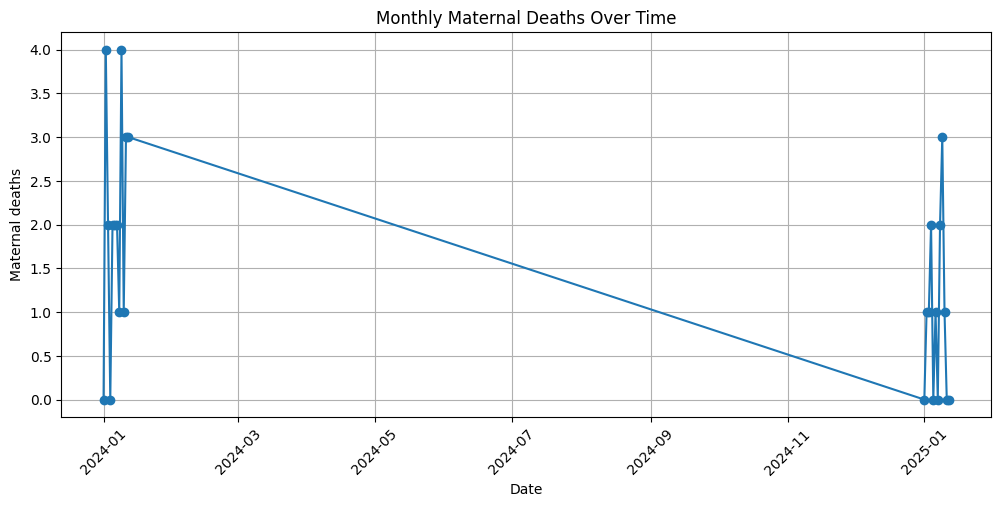

In [ ]:
plt.figure(figsize=(12, 5))

plt.plot(monthly["date"], monthly["maternal_deaths"], marker="o")

plt.title("Monthly Maternal Deaths Over Time")
plt.xlabel("Date")
plt.ylabel("Maternal deaths")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

# Add rolling avaerage

In [ ]:
monthly["maternal_deaths_3_month_rolling"] = monthly["maternal_deaths"].rolling(window=3).mean()

monthly.head()

,date,live_births,maternal_deaths,neonatal_deaths,deaths_notified_within_24h,deaths_reviewed_within_7d,actions_completed,data_completeness_pct,maternal_deaths_3_month_rolling
0,2024-01-01,2177,0,30,19,16,12,87.000000,NaN
1,2024-01-02,2286,4,36,28,20,15,85.666667,NaN
2,2024-01-03,2209,2,31,21,17,15,94.000000,2.000000
3,2024-01-04,2221,0,25,16,9,5,88.500000,2.000000
4,2024-01-05,2321,2,29,21,15,10,87.666667,1.333333


# Plot original line and rolling average

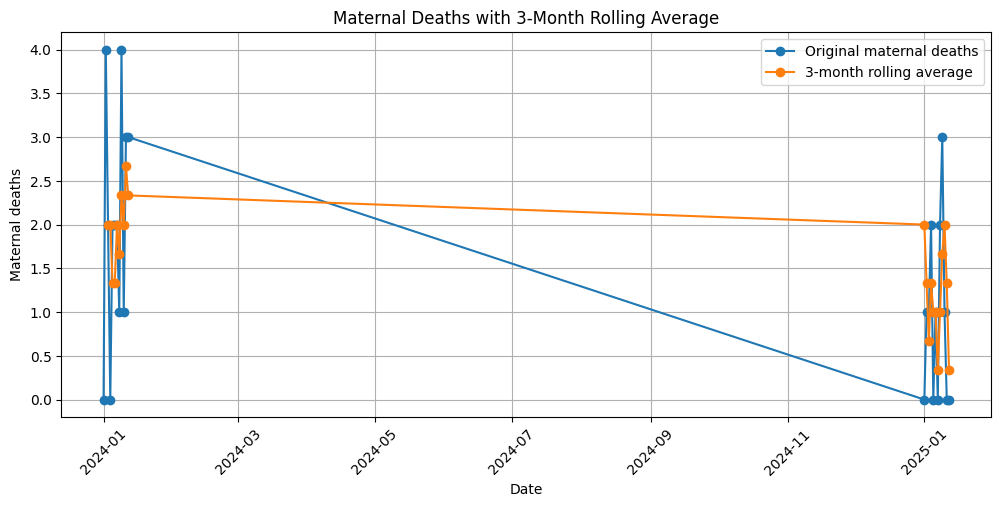

In [ ]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly["date"],
    monthly["maternal_deaths"],
    marker="o",
    label="Original maternal deaths"
)

plt.plot(
    monthly["date"],
    monthly["maternal_deaths_3_month_rolling"],
    marker="o",
    label="3-month rolling average"
)

plt.title("Maternal Deaths with 3-Month Rolling Average")
plt.xlabel("Date")
plt.ylabel("Maternal deaths")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.show()

# Plot neonatal deaths over time

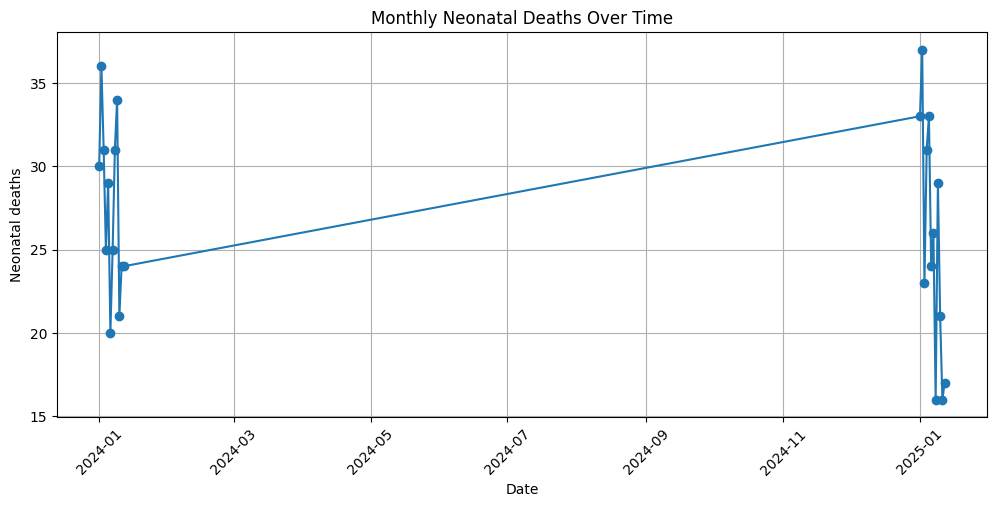

In [ ]:
plt.figure(figsize=(12, 5))

plt.plot(monthly["date"], monthly["neonatal_deaths"], marker="o")

plt.title("Monthly Neonatal Deaths Over Time")
plt.xlabel("Date")
plt.ylabel("Neonatal deaths")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

# Compare maternal and neonatal deaths

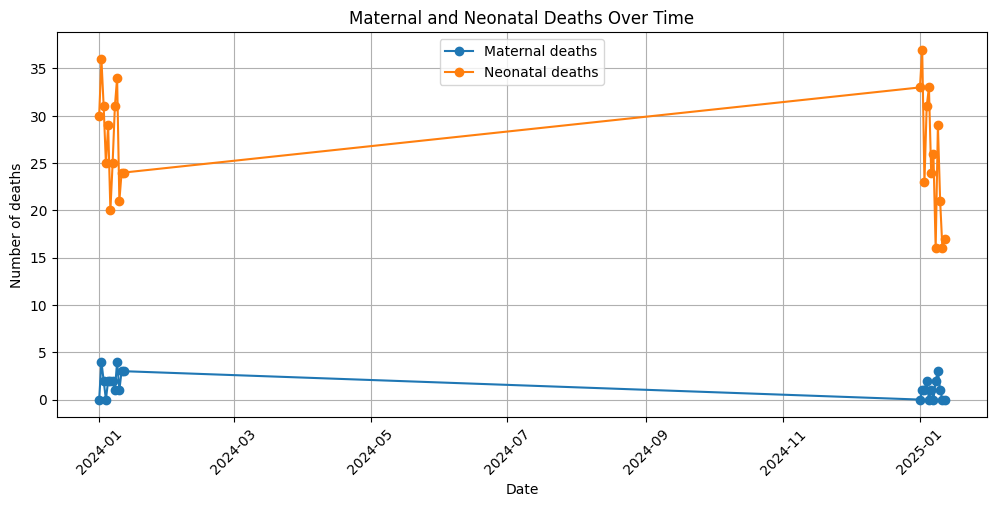

In [ ]:
plt.figure(figsize=(12, 5))

plt.plot(monthly["date"], monthly["maternal_deaths"], marker="o", label="Maternal deaths")
plt.plot(monthly["date"], monthly["neonatal_deaths"], marker="o", label="Neonatal deaths")

plt.title("Maternal and Neonatal Deaths Over Time")
plt.xlabel("Date")
plt.ylabel("Number of deaths")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.show()

# Plot by District

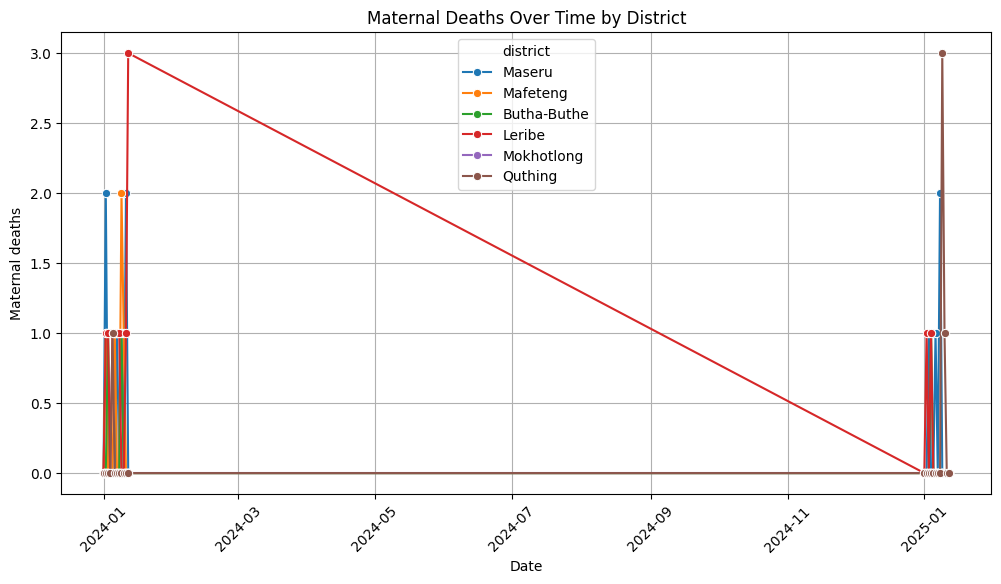

In [ ]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=df,
    x="date",
    y="maternal_deaths",
    hue="district",
    marker="o"
)

plt.title("Maternal Deaths Over Time by District")
plt.xlabel("Date")
plt.ylabel("Maternal deaths")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

# Time-series decomposition

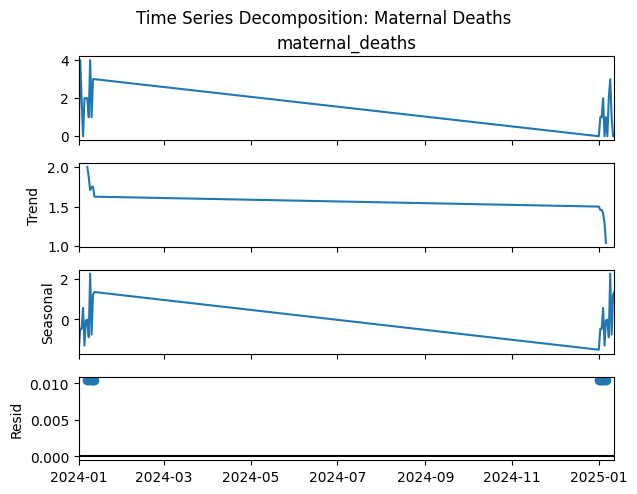

In [ ]:
monthly_indexed = monthly.set_index("date")

decomposition = seasonal_decompose(
    monthly_indexed["maternal_deaths"],
    model="additive",
    period=12
)

decomposition.plot()
plt.suptitle("Time Series Decomposition: Maternal Deaths", y=1.02)
plt.show()

# Stationarity test

In [ ]:
result = adfuller(monthly_indexed["maternal_deaths"])

print("ADF Statistic:", result[0])
print("p-value:", result[1])

if result[1] <= 0.05:
    print("The time series is likely stationary.")
else:
    print("The time series is likely NOT stationary.")

ADF Statistic: -0.6675373727201027
p-value: 0.8549798847804688
The time series is likely NOT stationary.


# Prepare data for prediction model

In [ ]:
df_model = df.copy()

df_model = df_model.sort_values(["district", "date"])

df_model["maternal_deaths_lag_1"] = df_model.groupby("district")["maternal_deaths"].shift(1)
df_model["maternal_deaths_lag_2"] = df_model.groupby("district")["maternal_deaths"].shift(2)
df_model["maternal_deaths_rolling_3"] = (
    df_model.groupby("district")["maternal_deaths"]
    .shift(1)
    .rolling(window=3)
    .mean()
)

df_model.head()

,date,year,month,district,live_births,maternal_deaths,neonatal_deaths,deaths_notified_within_24h,deaths_reviewed_within_7d,actions_completed,data_completeness_pct,maternal_deaths_lag_1,maternal_deaths_lag_2,maternal_deaths_rolling_3
48,2024-01-01,2024,1,Butha-Buthe,231,0,2,1,1,0,88,NaN,NaN,NaN
49,2024-01-02,2024,2,Butha-Buthe,256,0,7,6,4,2,89,0.0,NaN,NaN
50,2024-01-03,2024,3,Butha-Buthe,210,1,2,1,0,0,100,0.0,0.0,NaN
51,2024-01-04,2024,4,Butha-Buthe,270,0,4,3,1,0,82,1.0,0.0,0.333333
52,2024-01-05,2024,5,Butha-Buthe,223,0,4,3,1,0,87,0.0,1.0,0.333333


# Remove missing values created by lags

In [ ]:
df_model = df_model.dropna()

df_model.head()

,date,year,month,district,live_births,maternal_deaths,neonatal_deaths,deaths_notified_within_24h,deaths_reviewed_within_7d,actions_completed,data_completeness_pct,maternal_deaths_lag_1,maternal_deaths_lag_2,maternal_deaths_rolling_3
51,2024-01-04,2024,4,Butha-Buthe,270,0,4,3,1,0,82,1.0,0.0,0.333333
52,2024-01-05,2024,5,Butha-Buthe,223,0,4,3,1,0,87,0.0,1.0,0.333333
53,2024-01-06,2024,6,Butha-Buthe,251,0,1,0,0,0,90,0.0,0.0,0.333333
54,2024-01-07,2024,7,Butha-Buthe,219,0,3,3,1,1,92,0.0,0.0,0.000000
55,2024-01-08,2024,8,Butha-Buthe,269,0,6,5,4,2,80,0.0,0.0,0.000000


# Create features for machine **learning**

# maternal_deaths

In [ ]:
features = [
    "year",
    "month",
    "district",
    "live_births",
    "data_completeness_pct",
    "maternal_deaths_lag_1",
    "maternal_deaths_lag_2",
    "maternal_deaths_rolling_3"
]

target = "maternal_deaths"

X = df_model[features]
y = df_model[target]

X.head()

,year,month,district,live_births,data_completeness_pct,maternal_deaths_lag_1,maternal_deaths_lag_2,maternal_deaths_rolling_3
51,2024,4,Butha-Buthe,270,82,1.0,0.0,0.333333
52,2024,5,Butha-Buthe,223,87,0.0,1.0,0.333333
53,2024,6,Butha-Buthe,251,90,0.0,0.0,0.333333
54,2024,7,Butha-Buthe,219,92,0.0,0.0,0.000000
55,2024,8,Butha-Buthe,269,80,0.0,0.0,0.000000


# Convert district into numbers

In [ ]:
X_encoded = pd.get_dummies(X, columns=["district"], drop_first=True)

X_encoded.head()

,year,month,live_births,data_completeness_pct,maternal_deaths_lag_1,maternal_deaths_lag_2,maternal_deaths_rolling_3,district_Leribe,district_Mafeteng,district_Maseru,district_Mokhotlong,district_Quthing
51,2024,4,270,82,1.0,0.0,0.333333,False,False,False,False,False
52,2024,5,223,87,0.0,1.0,0.333333,False,False,False,False,False
53,2024,6,251,90,0.0,0.0,0.333333,False,False,False,False,False
54,2024,7,219,92,0.0,0.0,0.000000,False,False,False,False,False
55,2024,8,269,80,0.0,0.0,0.000000,False,False,False,False,False
